# Домашнее задание №1
## Часть 1: Механизм внимания (Attention)
##### Автор задания: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), https://t.me/s/rads_ai

В данном задании вам предстоит детально рассмотреть механизм Attention (и реализовать несколько его вариантов).

In [25]:
import os
import random

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from IPython.display import clear_output
%matplotlib inline

`import os` – для взаимодействия с операционной системой.  Чаще всего используется для работы с файловыми путями. Например, чтобы указать, откуда загрузить dataset (os.path.join('data', 'train.csv')), создать директории для сохранения моделей или проверить существование файла

`import random` – для генерации псевдослучайных чисел.Чтобы обеспечить воспроизводимость результатов (фиксируя seed — random.seed(42)), перемешивать данные в случайном порядке перед обучением или применять методы аугментации данных

`import numpy` – для работы с многомерными массивами (тензорами). Все операции с данными (линейная алгебра, статистика, преобразования) до того, как они попадут в нейросеть, обычно выполняются с помощью NumPy

`import pandas` – для работы с таблицами

`from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score`
* `roc_auc_score` – метрика для оценки качества бинарных классификаторов
* `roc_curve` – вычисляет точки для построения самой ROC-кривой (используется вместе с matplotlib для визуализации)
* `accuracy_score` – вычисляет простую точность (долю правильных ответов модели)

`import torch` – импорт основного модуля PyTorch. Это фреймворк для глубокого обучения с открытым исходным кодом. Определение тензоров (torch.Tensor), которые являются основным объектом для вычислений, и управление ими (включая вычисления на GPU)

`import torch.nn as nn` –  импорт модуля nn, который содержит все строительные блоки для нейронных сетей. Конкретное применение: Создание слоев нейронной сети (линейные nn.Linear, сверточные nn.Conv2d, RNN nn.LSTM), функций активации (nn.ReLU), функций потерь (nn.BCELoss, nn.CrossEntropyLoss) и собственных моделей через класс nn.Module

`import torch.nn.functional as F`– импорт функционального интерфейса для тех же операций, что и в nn, но в виде функций, а не классов. Конкретное применение: Содержит функции, которые не имеют обучаемых параметров (например, F.relu, F.max_pool2d, F.dropout). Часто используется для быстрого вызова функций прямо в forward-методе модели

`import matplotlib.pyplot as plt` – основная библиотека для построения графиков и визуализации в Python. Конкретное применение: Построение графиков обучения и валидации (loss/accuracy), отрисовка ROC-кривых, визуализация изображений или любых других данных

`from IPython.display import clear_output`– функция из среды Jupyter/IPython. Используется для динамического обновления вывода в ячейке блокнота. Чаще всего — в цикле обучения, чтобы очищать предыдущий вывод и рисовать обновленные графики на каждом шаге, создавая эффект "анимации".

`%matplotlib inline` – это не импорт библиотеки, а "magic-command" (магическая команда) Jupyter Notebook. Указывает Matplotlib отображать графики прямо в ноутбуке, под ячейкой с кодом, а не в отдельном окне. Это стандартная и обязательная практика для работы в Jupyter.

### Реализация Attention

В данной задаче вам предстоит реализовать механизм Attention, в частности несколько способов подсчета attention scores. Конечно, в популярных фреймворках данный механизм уже реализован, но для лучшего понимания вам предстаит реализовать его с помощью `numpy`.

Ваше задание в данной задаче: реализовать `additive` (аддитивный) и `multiplicative` (мультипликативный) варианты Attention. Для вашего удобства (и для примера) `dot product` attention (основанный на скалярном произведении) уже реализован.

Детальное описание данных типов Attention доступно в лекционных слайдах.

Text(0.5, 1.0, 'Decoder state')

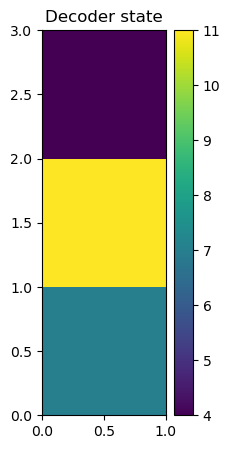

In [26]:
decoder_hidden_state = np.array([7, 11, 4]).astype(float)[:, None]

plt.figure(figsize=(2, 5))
plt.pcolormesh(decoder_hidden_state)
plt.colorbar()
plt.title("Decoder state")

Этот код создает визуализацию вектора скрытого состояния декодера (decoder hidden state) с помощью тепловой карты (heatmap).

`decoder_hidden_state = np.array([7, 11, 4]).astype(float)[:, None]` – создание вектора скрытого состояния:
* `np.array([7, 11, 4])` создает одномерный массив NumPy с тремя элементами: 7, 11 и 4
* `astype(float)` преобразует тип данных массива в float (числа с плавающей запятой)
* `[:, None]` — это трюк для изменения формы массива. None (или np.newaxis) добавляет новую ось, преобразуя одномерный массив формы (3,) в двумерный массив формы (3, 1) (3 строки, 1 столбец)
Итог: decoder_hidden_state теперь является столбцом:
[[ 7.]
 [11.]
 [ 4.]]


`plt.figure(figsize=(2, 5))` – cоздает новую фигуру для графика с шириной 2 дюйма и высотой 5 дюймов

`plt.pcolormesh(decoder_hidden_state)` 
`pcolormesh` создает тепловую карту из двумерного массива. Каждое значение в массиве отображается в виде цветного прямоугольника.
Поскольку наш массив имеет форму (3, 1), мы увидим 3 ячейки (по одной на каждое значение), расположенные вертикально. Цвет каждой ячейки будет соответствовать числовому значению: 7, 11 и 4

`plt.colorbar()` – добавляет рядом с графиком цветовую шкалу (legend), которая показывает, каким значениям соответствуют цвета

`plt.title("Decoder state")` – устанавливает заголовок графика "Decoder state"

#### Dot product attention (пример реализации)
Рассмотрим единственное состояние энкодера – вектор с размерностью `(n_hidden, 1)`, где `n_hidden = 3`:

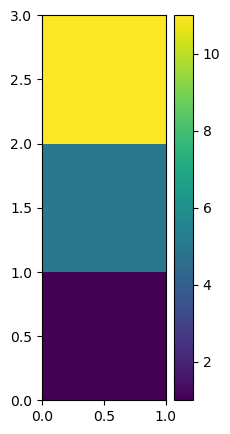

In [27]:
single_encoder_hidden_state = np.array([1, 5, 11]).astype(float)[:, None]

plt.figure(figsize=(2, 5))
plt.pcolormesh(single_encoder_hidden_state)
plt.colorbar()

Attention score между данными состояниями энкодера и декодера вычисляются просто как скалярное произведение:

In [28]:
np.dot(decoder_hidden_state.T, single_encoder_hidden_state)

array([[106.]])

Вычисление оценки внимания (между одним состоянием энкодера и декодером)

* `decoder_hidden_state.T` — транспонирование вектора состояния декодера (из формы (3, 1) в (1, 3))

* `np.dot` — вычисляет скалярное произведение между двумя векторами.
Результат: array([[106.]])

Что здесь происходит математически?
decoder_hidden_state.T = [7, 11, 4] (как строка)
single_encoder_hidden_state = [1, 5, 11]^T (как столбец)

Скалярное произведение:
(7 * 1) + (11 * 5) + (4 * 11) = 7 + 55 + 44 = 106

**Чем выше это число, тем более "релевантным" или "важным" считается данное состояние энкодера для текущего состояния декодера**

В общем случае состояний энкодера, конечно, несколько. Attention scores вычисляются с каждым из состояний энкодера:

In [29]:
encoder_hidden_states = (
    np.array([[1, 5, 11], [7, 4, 1], [8, 12, 2], [-9, 0, 1]]).astype(float).T
)

encoder_hidden_states

array([[ 1.,  7.,  8., -9.],
       [ 5.,  4., 12.,  0.],
       [11.,  1.,  2.,  1.]])

**Здесь создается не одно, а несколько состояний энкодера (4 состояния)**

Обратим внимание на .T в конце — транспонирование. Это критически важный шаг. Почему нужно транспонирование?

Исходный массив выглядит так:

[[ 1,  5, 11],
 [ 7,  4,  1],
 [ 8, 12,  2],
 [-9,  0,  1]]
Это 4 строки и 3 столбца. Каждая строка — это одно состояние энкодера.
Но в нейронных сетях принято, чтобы каждое состояние (вектор) было столбцом в матрице.
После транспонирования (.T) матрица принимает вид:

[[ 1.,  7.,  8., -9.],
 [ 5.,  4., 12.,  0.],
 [11.,  1.,  2.,  1.]]
 
 Теперь это 3 строки и 4 столбца. Каждый столбец — это одно состояние энкодера. Это стандартный формат.
 
 
**Логичным следующим шагом будет вычисление оценок внимания между состоянием декодера и каждым из 4-х состояний энкодера** Это делается одной операцией матричного умножения: `attention_scores = np.dot(decoder_hidden_state.T, encoder_hidden_states)`

Тогда для подсчета скалярных произведений между единственным состоянием декодера и всеми состояниями энкодера можно воспользоваться следующей функцией (которая по факту представляет собой просто матричное умножение и приведение типов):

In [30]:
def dot_product_attention_score(decoder_hidden_state, encoder_hidden_states):
    """
    decoder_hidden_state: np.array of shape (n_features, 1)
    encoder_hidden_states: np.array of shape (n_features, n_states)

    return: np.array of shape (1, n_states)
        Array with dot product attention scores
    """
    attention_scores = np.dot(decoder_hidden_state.T, encoder_hidden_states)
    return attention_scores

In [31]:
dot_product_attention_score(decoder_hidden_state, encoder_hidden_states)

array([[106.,  97., 196., -59.]])

Эта функция вычисляет сырые оценки внимания (raw attention scores) между текущим скрытым состоянием декодера и всеми скрытыми состояниями энкодера с помощью скалярного произведения.

Входные данные:
* `decoder_hidden_state`: Вектор размерности (n_features, 1), например [[7], [11], [4]]
* `encoder_hidden_states`: Матрица размерности (n_features, n_states), например:  
[[ 1.,  7.,  8., -9.],  
 [ 5.,  4., 12.,  0.],  
 [11.,  1.,  2.,  1.]]  

Операция транспонирования и умножения:
* `decoder_hidden_state.T` превращает вектор-столбец (3, 1) в вектор-строку (1, 3)
* `np.dot()` выполняет матричное умножение между:
- Вектором-строкой (1, 3) и
- Матрицей (3, 4)
Результатом будет вектор-строка (1, 4)

Для каждого столбца в encoder_hidden_states вычисляется скалярное произведение с decoder_hidden_state:

Для первого столбца [1, 5, 11]: (7×1) + (11×5) + (4×11) = 7 + 55 + 44 = 106  
Для второго столбца [7, 4, 1]: (7×7) + (11×4) + (4×1) = 49 + 44 + 4 = 97  
Для третьего столбца [8, 12, 2]: (7×8) + (11×12) + (4×2) = 56 + 132 + 8 = 196  
Для четвертого столбца [-9, 0, 1]: (7×-9) + (11×0) + (4×1) = -63 + 0 + 4 = -59  

Возвращаемый результат:  
**array([[106.,  97., 196., -59.]])  
Это и есть сырые оценки внимания — по одной для каждого состояния энкодера**

Что означают эти scores?

**Эти числа показывают степень соответствия между текущим состоянием декодера и каждым из состояний энкодера:**

- Высокие положительные значения (например, **196**) указывают на **сильную связь — состояние энкодера очень релевантно для текущего состояния декодера**
Низкие или отрицательные значения (например, **-59**) указывают на **слабую связь или даже "противоречие"**

Для подсчета "весов" нам необходим Softmax:

In [32]:
def softmax(vector):
    """
    vector: np.array of shape (n, m)

    return: np.array of shape (n, m)
        Matrix where softmax is computed for every row independently
    """
    nice_vector = vector - vector.max()
    exp_vector = np.exp(nice_vector)
    exp_denominator = np.sum(exp_vector, axis=1)[:, np.newaxis]
    softmax_ = exp_vector / exp_denominator
    return softmax_

In [33]:
weights_vector = softmax(
    dot_product_attention_score(decoder_hidden_state, encoder_hidden_states)
)

weights_vector

array([[8.19401262e-040, 1.01122149e-043, 1.00000000e+000,
        1.79848622e-111]])

Функция softmax **преобразует сырые оценки внимания [106., 97., 196., -59.] в вероятностное распределение:**  
weights_vector = [8.19401262e-040, 1.01122149e-043, 1.00000000e+000, 1.79848622e-111]  

- Почти весь вес (≈1.0) сосредоточен на третьем состоянии энкодера (индекс 2)  
- Остальные состояния практически игнорируются (веса чрезвычайно близки к 0)  


Математически это эквивалентно:  
attention_vector = Σ(weight_i * encoder_state_i)   
attention_vector ≈   
  8.19e-40 * [1, 5, 11] +   
  1.01e-43 * [7, 4, 1] +   
  1.00 * [8, 12, 2] +   
  1.80e-111 * [-9, 0, 1]  
≈ [0, 0, 0] + [0, 0, 0] + [8, 12, 2] + [0, 0, 0]  
= [8, 12, 2]  

Наконец, воспользуемся данными весами и вычислим итоговый вектор, как и описано для dot product attention.

[[ 8.]
 [12.]
 [ 2.]]


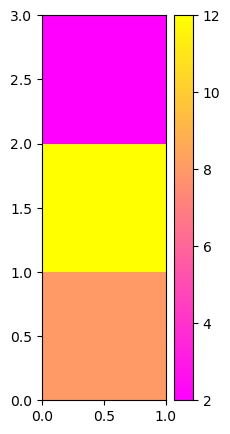

In [34]:
attention_vector = weights_vector.dot(encoder_hidden_states.T).T
print(attention_vector)

plt.figure(figsize=(2, 5))
plt.pcolormesh(attention_vector, cmap="spring")
plt.colorbar()

Эта строка вычисляет взвешенную сумму состояний энкодера:

- encoder_hidden_states.T — транспонирование матрицы состояний энкодера
- weights_vector.dot(...) — умножение вектора весов на матрицу состояний
.T — обратное транспонирование результата

Что происходит в итоге?  

Механизм внимания выполнил следующее:  

- Оценил важность: Определил, что третье состояние энкодера [8, 12, 2]   наиболее релевантно для текущего состояния декодера [7, 11, 4] (высокий score 196).   
- Сфокусировался: Назначил этому состоянию вес, практически равный 1, игнорируя все остальные состояния.  
- Сформировал контекст: Создал контекстный вектор [8, 12, 2], который представляет собой "выжимку" самой важной информации из всех состояний энкодера для текущего шага декодера.  

Данный вектор аккумулирует в себе информацию из всех состояний энкодера, взвешенную на основе близости к заданному состоянию декодера.

Реализуем все вышеописанные преобразования в единой функции:

In [35]:
def dot_product_attention(decoder_hidden_state, encoder_hidden_states):
    """
    decoder_hidden_state: np.array of shape (n_features, 1)
    encoder_hidden_states: np.array of shape (n_features, n_states)

    return: np.array of shape (n_features, 1)
        Final attention vector
    """
    softmax_vector = softmax(
        dot_product_attention_score(decoder_hidden_state, encoder_hidden_states)
    )
    attention_vector = softmax_vector.dot(encoder_hidden_states.T).T
    return attention_vector

In [36]:
assert (
    attention_vector
    == dot_product_attention(decoder_hidden_state, encoder_hidden_states)
).all()

#### Multiplicative attention
Ваша текущая задача: реализовать multiplicative attention.
$$ e_i = \mathbf{s}^TW_{mult}\mathbf{h}_i $$

Матрица весов `W_mult` задана ниже.
Стоит заметить, что multiplicative attention позволяет работать с состояниями энкодера и декодера различных размерностей, поэтому состояния энкодера будут обновлены:

In [37]:
encoder_hidden_states_complex = (
    np.array([[1, 5, 11, 4, -4], [7, 4, 1, 2, 2], [8, 12, 2, 11, 5], [-9, 0, 1, 8, 12]])
    .astype(float)
    .T
)

W_mult = np.array(
    [
        [-0.78, -0.97, -1.09, -1.79, 0.24],
        [0.04, -0.27, -0.98, -0.49, 0.52],
        [1.08, 0.91, -0.99, 2.04, -0.15],
    ]
)

Attention vector:
[[-9.00000000e+00]
 [ 1.01553049e-19]
 [ 1.00000000e+00]
 [ 8.00000000e+00]
 [ 1.20000000e+01]]


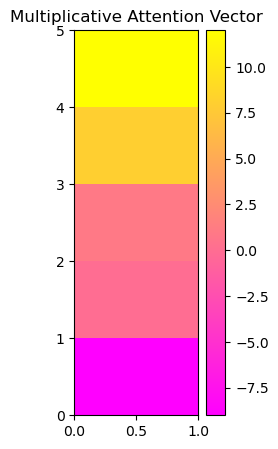

In [38]:
# МОЙ КОД:
import numpy as np

# Определяем функцию softmax (как в предыдущем примере)
def softmax(vector):
    """
    vector: np.array of shape (n, m)
    return: np.array of shape (n, m)
        Matrix where softmax is computed for every row independently
    """
    nice_vector = vector - vector.max()
    exp_vector = np.exp(nice_vector)
    exp_denominator = np.sum(exp_vector, axis=1)[:, np.newaxis]
    softmax_ = exp_vector / exp_denominator
    return softmax_

# Реализация multiplicative attention
def multiplicative_attention_score(decoder_hidden_state, encoder_hidden_states, W_mult):
    """
    decoder_hidden_state: np.array of shape (n_features_dec, 1)
    encoder_hidden_states: np.array of shape (n_features_enc, n_states)
    W_mult: np.array of shape (n_features_dec, n_features_enc)
    
    return: np.array of shape (1, n_states)
        Array with multiplicative attention scores
    """
    # Вычисляем scores: s^T * W_mult * h_i для каждого состояния энкодера
    # Эквивалентно: (decoder_hidden_state.T @ W_mult) @ encoder_hidden_states
    attention_scores = np.dot(np.dot(decoder_hidden_state.T, W_mult), encoder_hidden_states)
    return attention_scores

def multiplicative_attention(decoder_hidden_state, encoder_hidden_states, W_mult):
    """
    decoder_hidden_state: np.array of shape (n_features_dec, 1)
    encoder_hidden_states: np.array of shape (n_features_enc, n_states)
    W_mult: np.array of shape (n_features_dec, n_features_enc)
    
    return: np.array of shape (n_features_enc, 1)
        Final attention vector
    """
    # Вычисляем scores внимания
    attention_scores = multiplicative_attention_score(decoder_hidden_state, encoder_hidden_states, W_mult)
    
    # Применяем softmax для получения весов
    attention_weights = softmax(attention_scores)
    
    # Вычисляем взвешенную сумму состояний энкодера
    attention_vector = np.dot(encoder_hidden_states, attention_weights.T)
    
    return attention_vector

# Данные из условия
encoder_hidden_states_complex = (
    np.array([[1, 5, 11, 4, -4], [7, 4, 1, 2, 2], [8, 12, 2, 11, 5], [-9, 0, 1, 8, 12]])
    .astype(float)
    .T
)

W_mult = np.array(
    [
        [-0.78, -0.97, -1.09, -1.79, 0.24],
        [0.04, -0.27, -0.98, -0.49, 0.52],
        [1.08, 0.91, -0.99, 2.04, -0.15],
    ]
)

# Используем предыдущее состояние декодера
decoder_hidden_state = np.array([7, 11, 4]).astype(float)[:, None]

# Вычисляем attention
attention_vector = multiplicative_attention(decoder_hidden_state, encoder_hidden_states_complex, W_mult)

print("Attention vector:")
print(attention_vector)

# Визуализация
import matplotlib.pyplot as plt
plt.figure(figsize=(2, 5))
plt.pcolormesh(attention_vector, cmap="spring")
plt.colorbar()
plt.title("Multiplicative Attention Vector")
plt.show()

Реализуйте подсчет attention согласно формулам и реализуйте итоговую функцию `multiplicative_attention`:

In [41]:
def multiplicative_attention(decoder_hidden_state, encoder_hidden_states, W_mult):
    """
    decoder_hidden_state: np.array of shape (n_features_dec, 1)
    encoder_hidden_states: np.array of shape (n_features_enc, n_states)
    W_mult: np.array of shape (n_features_dec, n_features_enc)

    return: np.array of shape (n_features_enc, 1)
        Final attention vector
    """
    # Вычисляем attention scores: s^T * W_mult * H
    scores = decoder_hidden_state.T @ W_mult @ encoder_hidden_states
    # Применяем softmax к scores
    softmax_scores = softmax(scores)
    # Вычисляем взвешенную сумму состояний энкодера
    attention_vector = (softmax_scores @ encoder_hidden_states.T).T
    return attention_vector

#### Additive attention
Теперь вам предстоит реализовать additive attention.

$$ e_i = \mathbf{v}^T \text{tanh} (W_{add-enc} \mathbf{h}_i + W_{add-dec} \mathbf{s}) $$

Матрицы весов `W_add_enc` и `W_add_dec` доступны ниже, как и вектор весов `v_add`. Для вычисления активации можно воспользоваться `np.tanh`.

In [42]:
v_add = np.array([[-0.35, -0.58, 0.07, 1.39, -0.79, -1.78, -0.35]]).T

W_add_enc = np.array(
    [
        [-1.34, -0.1, -0.38, 0.12, -0.34],
        [-1.0, 1.28, 0.49, -0.41, -0.32],
        [-0.39, -1.38, 1.26, 1.21, 0.15],
        [-0.18, 0.04, 1.36, -1.18, -0.53],
        [-0.23, 0.96, 1.02, 0.39, -1.26],
        [-1.27, 0.89, -0.85, -0.01, -1.19],
        [0.46, -0.12, -0.86, -0.93, -0.4],
    ]
)

W_add_dec = np.array(
    [
        [-1.62, -0.02, -0.39],
        [0.43, 0.61, -0.23],
        [-1.5, -0.43, -0.91],
        [-0.14, 0.03, 0.05],
        [0.85, 0.51, 0.63],
        [0.39, -0.42, 1.34],
        [-0.47, -0.31, -1.34],
    ]
)

Attention vector:
[[4.64510711]
 [6.6372749 ]
 [3.11601386]
 [6.2104178 ]
 [3.06285127]]


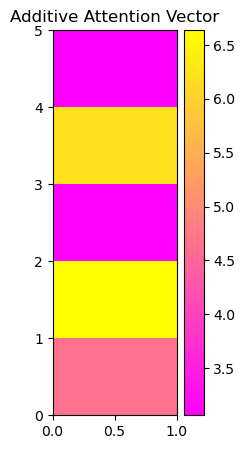

In [43]:
# МОЙ КОД:
import numpy as np

# Определяем функцию softmax
def softmax(vector):
    """
    vector: np.array of shape (n, m)
    return: np.array of shape (n, m)
        Matrix where softmax is computed for every row independently
    """
    nice_vector = vector - vector.max()
    exp_vector = np.exp(nice_vector)
    exp_denominator = np.sum(exp_vector, axis=1)[:, np.newaxis]
    softmax_ = exp_vector / exp_denominator
    return softmax_

# Реализация additive attention
def additive_attention_score(decoder_hidden_state, encoder_hidden_states, W_add_enc, W_add_dec, v_add):
    """
    decoder_hidden_state: np.array of shape (n_features_dec, 1)
    encoder_hidden_states: np.array of shape (n_features_enc, n_states)
    W_add_enc: np.array of shape (hidden_dim, n_features_enc)
    W_add_dec: np.array of shape (hidden_dim, n_features_dec)
    v_add: np.array of shape (hidden_dim, 1)
    
    return: np.array of shape (1, n_states)
        Array with additive attention scores
    """
    # Вычисляем W_add_enc * h_i для всех состояний энкодера
    W_enc_h = np.dot(W_add_enc, encoder_hidden_states)  # (7, 4)
    
    # Вычисляем W_add_dec * s
    W_dec_s = np.dot(W_add_dec, decoder_hidden_state)  # (7, 1)
    
    # Складываем и применяем tanh (бродкастинг автоматически добавляет W_dec_s к каждому столбцу W_enc_h)
    temp = np.tanh(W_enc_h + W_dec_s)  # (7, 4)
    
    # Вычисляем v^T * tanh(...)
    attention_scores = np.dot(v_add.T, temp)  # (1, 4)
    
    return attention_scores

def additive_attention(decoder_hidden_state, encoder_hidden_states, W_add_enc, W_add_dec, v_add):
    """
    decoder_hidden_state: np.array of shape (n_features_dec, 1)
    encoder_hidden_states: np.array of shape (n_features_enc, n_states)
    W_add_enc: np.array of shape (hidden_dim, n_features_enc)
    W_add_dec: np.array of shape (hidden_dim, n_features_dec)
    v_add: np.array of shape (hidden_dim, 1)
    
    return: np.array of shape (n_features_enc, 1)
        Final attention vector
    """
    # Вычисляем scores внимания
    attention_scores = additive_attention_score(decoder_hidden_state, encoder_hidden_states, 
                                               W_add_enc, W_add_dec, v_add)
    
    # Применяем softmax для получения весов
    attention_weights = softmax(attention_scores)  # (1, 4)
    
    # Вычисляем взвешенную сумму состояний энкодера
    attention_vector = np.dot(encoder_hidden_states, attention_weights.T)  # (5, 4) * (4, 1) = (5, 1)
    
    return attention_vector

# Данные из условия
encoder_hidden_states_complex = (
    np.array([[1, 5, 11, 4, -4], [7, 4, 1, 2, 2], [8, 12, 2, 11, 5], [-9, 0, 1, 8, 12]])
    .astype(float)
    .T
)

W_add_enc = np.array(
    [
        [-1.34, -0.1, -0.38, 0.12, -0.34],
        [-1.0, 1.28, 0.49, -0.41, -0.32],
        [-0.39, -1.38, 1.26, 1.21, 0.15],
        [-0.18, 0.04, 1.36, -1.18, -0.53],
        [-0.23, 0.96, 1.02, 0.39, -1.26],
        [-1.27, 0.89, -0.85, -0.01, -1.19],
        [0.46, -0.12, -0.86, -0.93, -0.4],
    ]
)

W_add_dec = np.array(
    [
        [-1.62, -0.02, -0.39],
        [0.43, 0.61, -0.23],
        [-1.5, -0.43, -0.91],
        [-0.14, 0.03, 0.05],
        [0.85, 0.51, 0.63],
        [0.39, -0.42, 1.34],
        [-0.47, -0.31, -1.34],
    ]
)

v_add = np.array([[-0.35, -0.58, 0.07, 1.39, -0.79, -1.78, -0.35]]).T

# Используем предыдущее состояние декодера
decoder_hidden_state = np.array([7, 11, 4]).astype(float)[:, None]

# Вычисляем attention
attention_vector = additive_attention(decoder_hidden_state, encoder_hidden_states_complex, 
                                    W_add_enc, W_add_dec, v_add)

print("Attention vector:")
print(attention_vector)

# Визуализация
import matplotlib.pyplot as plt
plt.figure(figsize=(2, 5))
plt.pcolormesh(attention_vector, cmap="spring")
plt.colorbar()
plt.title("Additive Attention Vector")
plt.show()

Реализуйте подсчет attention согласно формулам и реализуйте итоговую функцию `additive_attention`:

In [44]:
def additive_attention(
    decoder_hidden_state, encoder_hidden_states, v_add, W_add_enc, W_add_dec
):
    """
    decoder_hidden_state: np.array of shape (n_features_dec, 1)
    encoder_hidden_states: np.array of shape (n_features_enc, n_states)
    v_add: np.array of shape (n_features_int, 1)
    W_add_enc: np.array of shape (n_features_int, n_features_enc)
    W_add_dec: np.array of shape (n_features_int, n_features_dec)

    return: np.array of shape (n_features_enc, 1)
        Final attention vector
    """
    # Вычисляем W_add_enc * H
    enc_proj = W_add_enc @ encoder_hidden_states
    # Вычисляем W_add_dec * s и расширяем до размеров enc_proj
    dec_proj = W_add_dec @ decoder_hidden_state
    # Складываем и применяем tanh
    intermediate = np.tanh(enc_proj + dec_proj)
    # Вычисляем scores: v^T * intermediate
    scores = v_add.T @ intermediate
    # Применяем softmax к scores
    softmax_scores = softmax(scores)
    # Вычисляем взвешенную сумму состояний энкодера
    attention_vector = (softmax_scores @ encoder_hidden_states.T).T
    return attention_vector

In [45]:
out_dict = {
    'multiplicative_attention': multiplicative_attention,
    'additive_attention': additive_attention
}

Сдайте функции `multiplicative_attention` и `additive_attention` в контест.

Не забудьте про импорт `numpy`!

In [46]:
# do not change the code in the block below
# __________start of block__________

np.save("submission_dict_hw08.npy", out_dict, allow_pickle=True)
print("File saved to `submission_dict_hw08.npy`")
# __________end of block__________

File saved to `submission_dict_hw08.npy`


На этом задание завершено. Поздравляем!